In [ ]:
#实例化一个Sequential块并将需要的层连接在一起
import torch
from torch import nn
from d2l import torch as d2l

class Reshape(torch.nn.Module):
    def forward(self,x):
        return x.view(-1,1,28,28)
    
net=nn.Sequential(
    Reshape(),nn.Conv2d(1,6,kernel_size=5,padding=2),nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2,stride=2),
    nn.Conv2d(6,16,kernel_size=5),nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2,stride=2),nn.Flatten(),
    nn.Linear(16*5*5,120),nn.Sigmoid(),
    nn.Linear(120,84),nn.Sigmoid(),
    nn.Linear(84,10)
)

In [ ]:
#模型检查
X=torch.rand(size=(1,1,28,28),dtype=torch.float32)
for layer in net:
    X=layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

In [ ]:
#LeNet在Fashion-MNIST数据集上的表现
batch_size=256
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size=batch_size)

In [ ]:
#对evaluate_accuracy函数进行轻微的修改
def evaluate_accuracy_gpu(net,data_iter,device=None):
    if isinstance(net,torch.nn.Module):
        net.eval()
        if not device:
            device=next(iter(net.parameters())).device
    metric=d2l.Accumulator(2)
    for X,y in data_iter:
        if isinstance(X,list):
            X=[x.to(device) for x in X]
        else:
            X=X.to(device)
        y=y.to(device)
        metric.add(d2l.accuracy(net(X),y),y.numel())
    return metric[0]/metric[1]

In [15]:
def train_ch6(net,train_iter,test_iter,num_epochs,lr,device):
    def init_weight(m):
        if type(m)==nn.Linear or type(m)==nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weight)
    print('trianing on',device)
    net.to(device)
    optimizer=torch.optim.AdamW(net.parameters(),lr=lr,weight_decay=1e-6)
    loss=nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)

#训练循环
    for epoch in range(num_epochs):
        metric=d2l.Accumulator(5)
        net.train()
        for i ,(X,y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X,y=X.to(device),y.to(device)
            y_hat=net(X)
            l=loss(y_hat,y)
            l.backward()
            optimizer.step()
            metric.add(l*X.shape[0],d2l.accuracy(y_hat,y),X.shape[0])
            timer.stop()
            train_l=metric[0]/metric[2]
            train_acc=metric[1]/metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

loss 0.266, train acc 0.902, test acc 0.889
78048.2 examples/sec on cuda:0


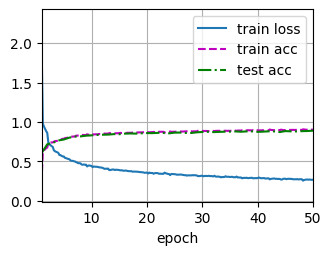

In [16]:
#评估LeNet-5模型
lr,num_epochs=0.001,50
train_ch6(net,train_iter,test_iter,num_epochs,lr,d2l.try_gpu())